**Import the relevant libraries**

In [194]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3


Step 1. is to import the csv file that has been provided to a pandas dataframe.

*NB. The origional dataset uses memery at circa. 1.7KB, a further convertion to Boolean will reduce the memory usage.*

In [195]:
data = pd.read_csv('Task 3 Covid.csv')

In [196]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Person             50 non-null     int64 
 1   Safe for Vaccine   50 non-null     object
 2   Faith in Vac-Jab1  50 non-null     object
 3   Faith in Vac-Jab2  50 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.7+ KB


In [197]:
print(data.head())

   Person Safe for Vaccine Faith in Vac-Jab1 Faith in Vac-Jab2
0       1              Yes               Yes               Yes
1       2              Yes               Yes                No
2       3              Yes                No               Yes
3       4               No               Yes                No
4       5               No                No               Yes


In [198]:
# Set of people who answered "Yes" for Vac-Jab1 and Vac-Jab2
vac_jab1_yes = set(data[data['Faith in Vac-Jab1'] == 'Yes']['Person'])
vac_jab2_yes = set(data[data['Faith in Vac-Jab2'] == 'Yes']['Person'])

# Calculate intersections and differences
only_vac_jab1_yes = vac_jab1_yes - vac_jab2_yes
only_vac_jab2_yes = vac_jab2_yes - vac_jab1_yes
both_yes = vac_jab1_yes & vac_jab2_yes

# Print some basic stats
print("People who answered 'Yes' to Vac-Jab1 only:", len(only_vac_jab1_yes))
print("People who answered 'Yes' to Vac-Jab2 only:", len(only_vac_jab2_yes))
print("People who answered 'Yes' to both Vac-Jab1 and Vac-Jab2:", len(both_yes))
print("Total number of people in dataset:", len(data))

People who answered 'Yes' to Vac-Jab1 only: 8
People who answered 'Yes' to Vac-Jab2 only: 12
People who answered 'Yes' to both Vac-Jab1 and Vac-Jab2: 14
Total number of people in dataset: 50


--------
Step 2. Check the String values for anything other then "yes or "no", I will be converting the strings to boolean so will need to check teh dataset for any other values.

In [199]:
## create a variable to hold the count if yes
yes_counts = (data == 'Yes').sum()
print("Count of 'Yes' in each column:")
print(yes_counts)

print()
## create a variable to hold the count if no
no_counts = (data == 'No').sum()
print("Count of 'No' in each column:")
print(no_counts)

print()
# create a variable and count occurrences of values other than 'Yes' or 'No'
other_counts = (data != 'Yes') & (data != 'No')  # Identify values that are neither 'Yes' nor 'No'
other_counts_total = other_counts.sum()
print ("** THIS IS THE IMPORTANT RETURN **")
print("Count of values other than 'Yes' or 'No' in each column:")
print(other_counts_total)

Count of 'Yes' in each column:
Person                0
Safe for Vaccine     20
Faith in Vac-Jab1    22
Faith in Vac-Jab2    26
dtype: int64

Count of 'No' in each column:
Person                0
Safe for Vaccine     30
Faith in Vac-Jab1    28
Faith in Vac-Jab2    24
dtype: int64

** THIS IS THE IMPORTANT RETURN **
Count of values other than 'Yes' or 'No' in each column:
Person               50
Safe for Vaccine      0
Faith in Vac-Jab1     0
Faith in Vac-Jab2     0
dtype: int64


-----------
Step 3. Convert the Strings value to boolean values, the aim here is to reduce the memary usage. I have also taken the opportunity to set the dataframe index as the Person Id.

*NB. This algorithum is converting the same dataframe (data), it will show an error is the algorithum is not re run from teh start each time.*

In [200]:
## Set the index to become the first column with the Person Id
data = data.set_index('Person')

# Define the columns to convert
columns_to_convert = ['Safe for Vaccine', 'Faith in Vac-Jab1', 'Faith in Vac-Jab2']

# Convert 'Yes' to True and 'No' to False in the specified columns
data[columns_to_convert] = data[columns_to_convert].replace({'Yes': True, 'No': False})

# Display the updated DataFrame
print(data)

        Safe for Vaccine  Faith in Vac-Jab1  Faith in Vac-Jab2
Person                                                        
1                   True               True               True
2                   True               True              False
3                   True              False               True
4                  False               True              False
5                  False              False               True
6                  False               True               True
7                   True              False              False
8                  False              False              False
9                  False              False               True
10                 False               True               True
11                  True              False              False
12                 False              False              False
13                  True               True               True
14                  True               True            

In [201]:
## Checks data type changes and memory usage has been reduced
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 50 entries, 1 to 50
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Safe for Vaccine   50 non-null     bool 
 1   Faith in Vac-Jab1  50 non-null     bool 
 2   Faith in Vac-Jab2  50 non-null     bool 
dtypes: bool(3)
memory usage: 550.0 bytes


-----------
Step 4. This is creating the Venn diagram, first I have created a Variable to hold each of the permutations ​of teh Boolean logic. Each Variable then prints a count to cross check the Venn diagram results.

In [202]:
# Count combinations for Venn diagram
yesAll = ((data['Safe for Vaccine'] == 1) & 
           (data['Faith in Vac-Jab1'] == 1) & 
           (data['Faith in Vac-Jab2'] == 1)).sum()

safeSomefaith1 = ((data['Safe for Vaccine'] == 1) & 
                 (data['Faith in Vac-Jab1'] == 1) & 
                 (data['Faith in Vac-Jab2'] == 0)).sum()

safeNoFaith = ((data['Safe for Vaccine'] == 1) & 
                 (data['Faith in Vac-Jab1'] == 0) & 
                 (data['Faith in Vac-Jab2'] == 0)).sum()

safeSomeFaith2 = ((data['Safe for Vaccine'] == 1) & 
                 (data['Faith in Vac-Jab1'] == 0) & 
                 (data['Faith in Vac-Jab2'] == 1)).sum()

noSafeFaith1 = ((data['Safe for Vaccine'] == 0) & 
                 (data['Faith in Vac-Jab1'] == 1) & 
                 (data['Faith in Vac-Jab2'] == 0)).sum()

noSafeFaith2 = ((data['Safe for Vaccine'] == 0) & 
                 (data['Faith in Vac-Jab1'] == 1) & 
                 (data['Faith in Vac-Jab2'] == 1)).sum()

noSafeFaith3 = ((data['Safe for Vaccine'] == 0) & 
                 (data['Faith in Vac-Jab1'] == 0) & 
                 (data['Faith in Vac-Jab2'] == 1)).sum()

noAll = ((data['Safe for Vaccine'] == 0) & 
          (data['Faith in Vac-Jab1'] == 0) & 
          (data['Faith in Vac-Jab2'] == 0)).sum()

print("Each of the these print statements can be used to cross check the Venn diagram results")
print (yesAll,"= Safe with full faith")
print (safeSomefaith1,"= Safe with faith in jab 1")
print (safeNoFaith,"= Safe but no faith in jabs")
print (safeSomeFaith2, "= Safe with faith in jab 2")
print (noSafeFaith1,"= Not safe but faith in jab 1")
print (noSafeFaith2,"= Not Safe but faith in both jabs")
print (noSafeFaith3,"= Not Safe but faith in jab 2")
print (noAll,"= Not safe, and no faith")

Each of the these print statements can be used to cross check the Venn diagram results
5 = Safe with full faith
4 = Safe with faith in jab 1
9 = Safe but no faith in jabs
2 = Safe with faith in jab 2
4 = Not safe but faith in jab 1
9 = Not Safe but faith in both jabs
10 = Not Safe but faith in jab 2
7 = Not safe, and no faith


-------------
Step 5. Create the actual Venn diagram, to do this I have created a Dictionary. Each key in the dictionary represents a combination of set membership for three sets, and each corresponding value is a variable that holds the data for the number of elements that belong to the respective combination of sets.

 - The keys in the dictionary ('111', '110', '100', etc.) represent all possible combinations of membership for the three sets.
 - '1' means that the item is part of that set.
 - '0' means the item is not part of that set.
 
 **Using the matplotlib function**
 
venn3 ia a function from the matplotlib library, which creates a Venn diagram for three sets. The subsets=venn_data argument is passed to provide the data from the dictionary above.

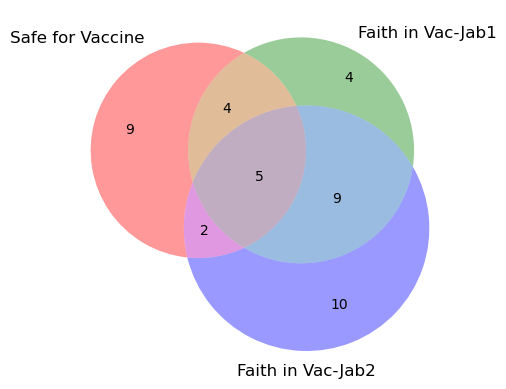

In [203]:
venn_data = {
    '111': yesAll,            
    '110': safeSomefaith1,    
    '100': safeNoFaith,       
    '101': safeSomeFaith2,    
    '010': noSafeFaith1,      
    '011': noSafeFaith2,
    '001': noSafeFaith3,      
    '000': noAll,            
}

# Create the Venn diagram
venn3(subsets=venn_data, set_labels=('Safe for Vaccine', 'Faith in Vac-Jab1', 'Faith in Vac-Jab2'))

# Display the plot
plt.show()

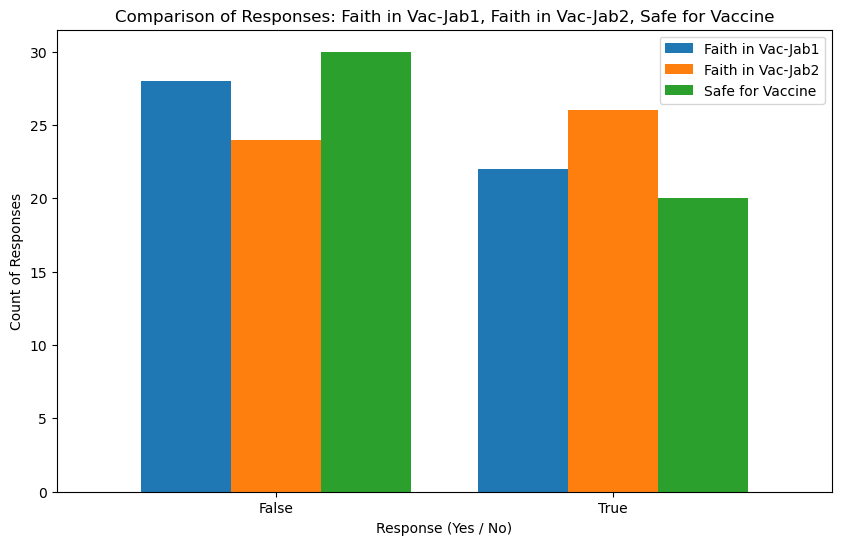

In [213]:
# Count "Yes" and "No" responses for each question
vac_jab1_counts = data['Faith in Vac-Jab1'].value_counts()
vac_jab2_counts = data['Faith in Vac-Jab2'].value_counts()
safe_for_vaccine_counts = data['Safe for Vaccine'].value_counts()

counts_data = pd.DataFrame({
    'Faith in Vac-Jab1': vac_jab1_counts,
    'Faith in Vac-Jab2': vac_jab2_counts,
    'Safe for Vaccine': safe_for_vaccine_counts
})
counts_data.plot(kind='bar', figsize=(10, 6), width=0.8)

# Adding labels and title
plt.title('Comparison of Responses: Faith in Vac-Jab1, Faith in Vac-Jab2, Safe for Vaccine')
plt.ylabel('Count of Responses')
plt.xlabel('Response (Yes / No)')
plt.xticks(rotation=0)  # Keep the x-axis labels horizontal

# Show the plot
plt.show()


In [233]:
counts_data2 = pd.DataFrame({
    'Safe for Vaccine': safe_for_vaccine_counts,
    'Faith in Vac-Jab1': vac_jab1_counts,
    'Faith in Vac-Jab2': vac_jab2_counts
})
print(counts_data2)

       Safe for Vaccine  Faith in Vac-Jab1  Faith in Vac-Jab2
False                30                 28                 24
True                 20                 22                 26


In [230]:
## Transpose the data frame 
counts_data2_transposed = counts_data2.T

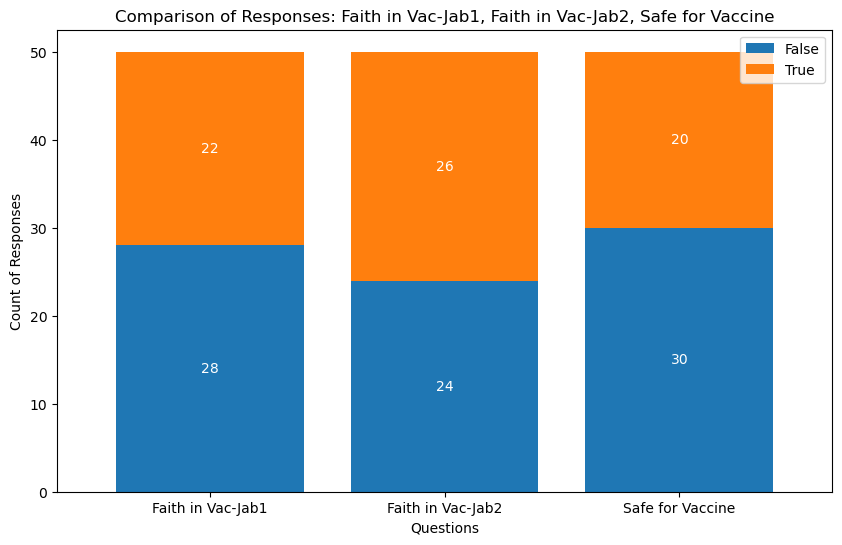

In [231]:
ax = counts_data2_transposed.plot(kind='bar', stacked=True, figsize=(10, 6), width=0.8, color=['#1f77b4', '#ff7f0e'])

# Add values on top of the bars
for p in ax.patches:
    height = p.get_height()  # Get the height of the current bar segment
    width = p.get_width()    # Get the width of the current bar segment
    x = p.get_x() + width / 2  # X position to place the label (center of the bar)
    y = p.get_y() + height / 2 # Y position to place the label (middle of the bar segment)
    
    # Add the label (use int() to show integer values)
    ax.text(x, y, str(int(height)), ha='center', va='center', fontsize=10, color='white')

# Adding labels and title
plt.title('Comparison of Responses: Faith in Vac-Jab1, Faith in Vac-Jab2, Safe for Vaccine')
plt.ylabel('Count of Responses')
plt.xlabel('Questions')
plt.xticks(rotation=0)  # Keep the x-axis labels horizontal

# Show the plot
plt.show()